---
# Import Libraries and Load Dataset



In [ ]:
# Import pandas for dataframes
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for statistical data visualization
import seaborn as sns

# Import os for file path operations
import os

# Set seaborn theme style for clean visual output
sns.set_theme(style="whitegrid")

# Configure pandas to display all columns when printing tables
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")


All libraries imported successfully!


### Loading the Raw Dataset



In [12]:
# Define path to the CSV dataset
data_path = os.path.join("..", "data", "raw", "House_Prices.csv")

# If notebook is run directly from root directory instead of notebooks/
if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw", "House_Prices.csv")

print("Loading data from:", data_path)

# Read CSV file using pandas
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Number of rows (houses):", df.shape[0])
print("Number of columns (features + target):", df.shape[1])


Loading data from: ..\data\raw\House_Prices.csv
Dataset loaded successfully!
Number of rows (houses): 2919
Number of columns (features + target): 81


---
# 1. SalePrice Distribution



--- SalePrice Summary Statistics ---
count      2919.000000
mean     180052.854647
std       57381.565721
min       34900.000000
25%      154795.084126
50%      176734.841494
75%      191895.744157
max      755000.000000
Name: SalePrice, dtype: float64

Mean Price:  $ 180052.85
Median Price: $ 176734.84
Skewness:      2.55


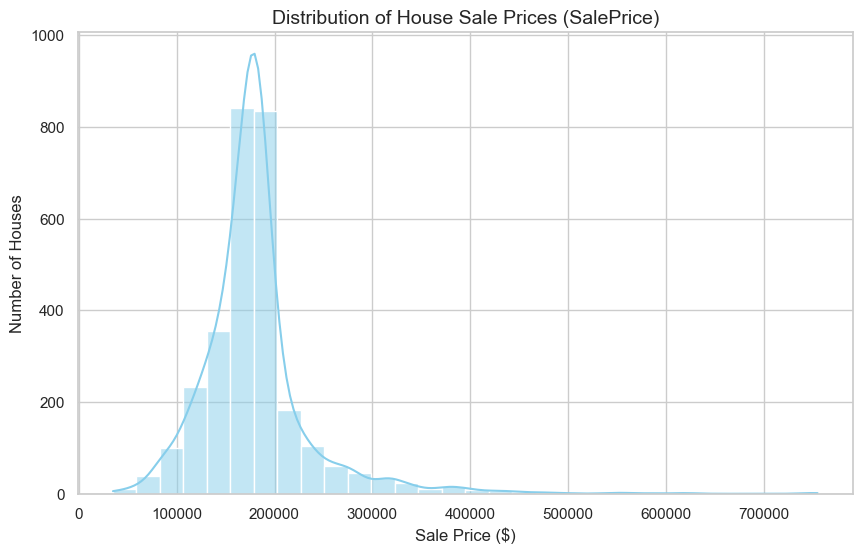

In [ ]:
# Display summary statistics of SalePrice
print("--- SalePrice Summary Statistics ---")
print(df["SalePrice"].describe())

# Calculate mean, median, and skewness
mean_price = df["SalePrice"].mean()
median_price = df["SalePrice"].median()
price_skewness = df["SalePrice"].skew()

print("\nMean Price:  $", round(mean_price, 2))
print("Median Price: $", round(median_price, 2))
print("Skewness:     ", round(price_skewness, 2))

# Plot SalePrice distribution with a Histogram and KDE curve
plt.figure(figsize=(10, 6))
sns.histplot(df["SalePrice"], kde=True, color="skyblue", bins=30)

# Add titles and labels
plt.title("Distribution of House Sale Prices (SalePrice)", fontsize=14)
plt.xlabel("Sale Price ($)", fontsize=12)
plt.ylabel("Number of Houses", fontsize=12)

# Show plot
plt.show()


---
# 2. Living Area vs SalePrice



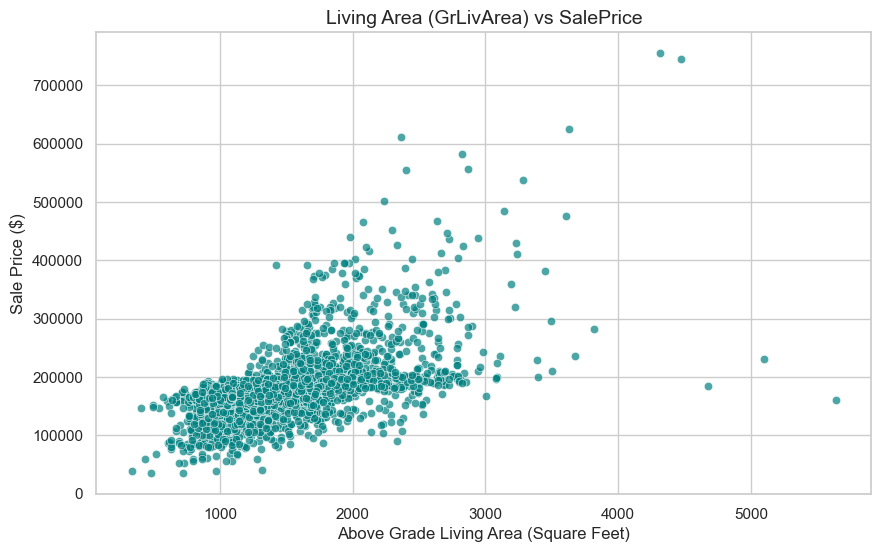

In [ ]:
# Create a scatter plot of Living Area vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], alpha=0.7, color="teal")

# Add title and labels
plt.title("Living Area (GrLivArea) vs SalePrice", fontsize=14)
plt.xlabel("Above Grade Living Area (Square Feet)", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)

# Display graph
plt.show()


---
# 3. Overall Quality vs SalePrice



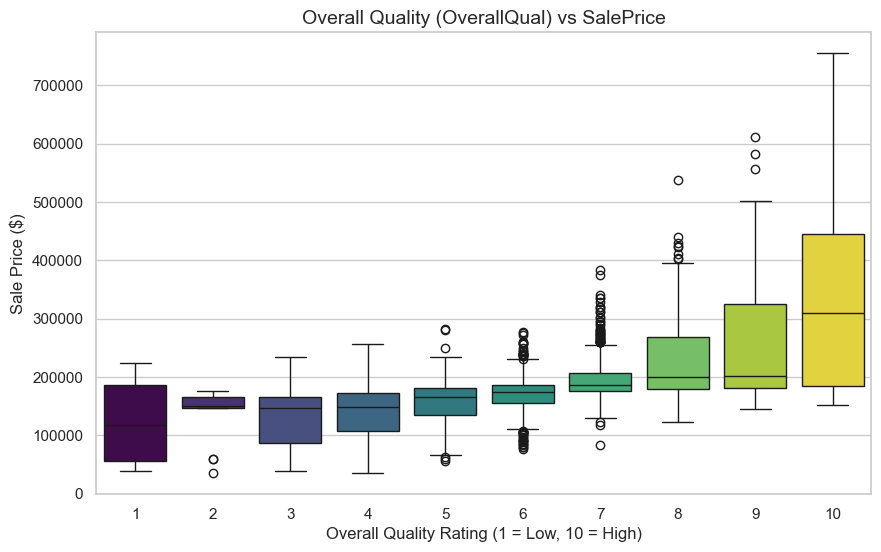

In [ ]:
# Create a Boxplot of Overall Quality vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"], hue=df["OverallQual"], palette="viridis", legend=False)

# Add title and axis labels
plt.title("Overall Quality (OverallQual) vs SalePrice", fontsize=14)
plt.xlabel("Overall Quality Rating (1 = Low, 10 = High)", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)

# Display graph
plt.show()


---
# 4. Neighborhood vs SalePrice



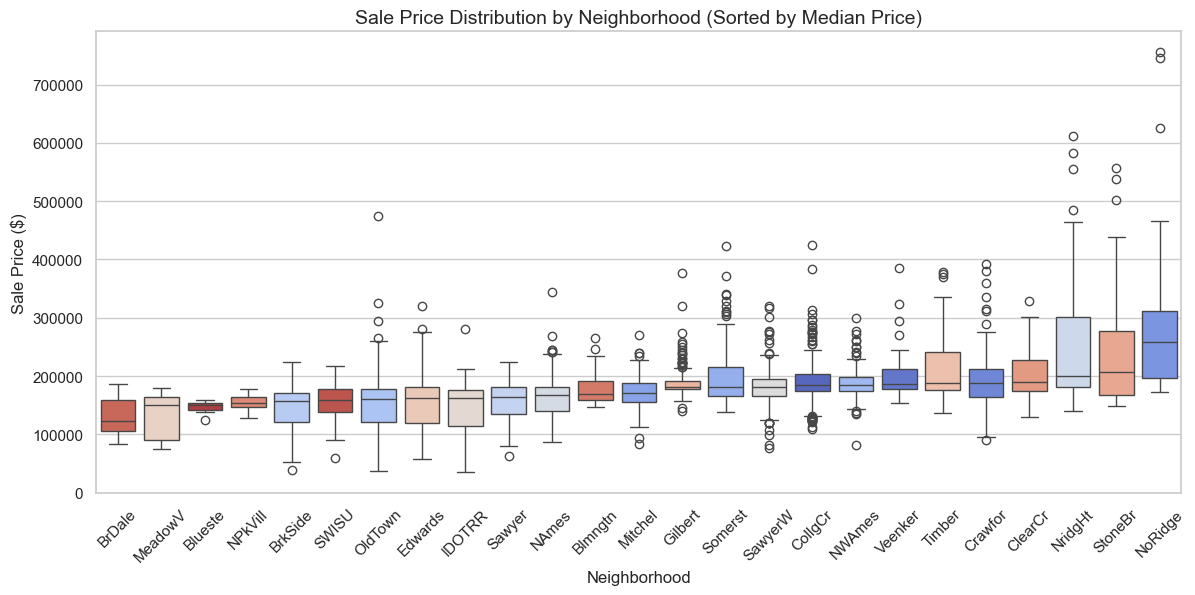

In [7]:
# Calculate median price for each neighborhood to sort them cleanly
neighborhood_order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index

# Create a boxplot sorted by median neighborhood price
plt.figure(figsize=(14, 6))
sns.boxplot(x=df["Neighborhood"], y=df["SalePrice"], order=neighborhood_order, hue=df["Neighborhood"], palette="coolwarm", legend=False)

# Rotate x-axis labels so all neighborhood names are easy to read
plt.xticks(rotation=45)

# Add title and labels
plt.title("Sale Price Distribution by Neighborhood (Sorted by Median Price)", fontsize=14)
plt.xlabel("Neighborhood", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)

# Display graph
plt.show()


---
# 5. Year Built vs SalePrice



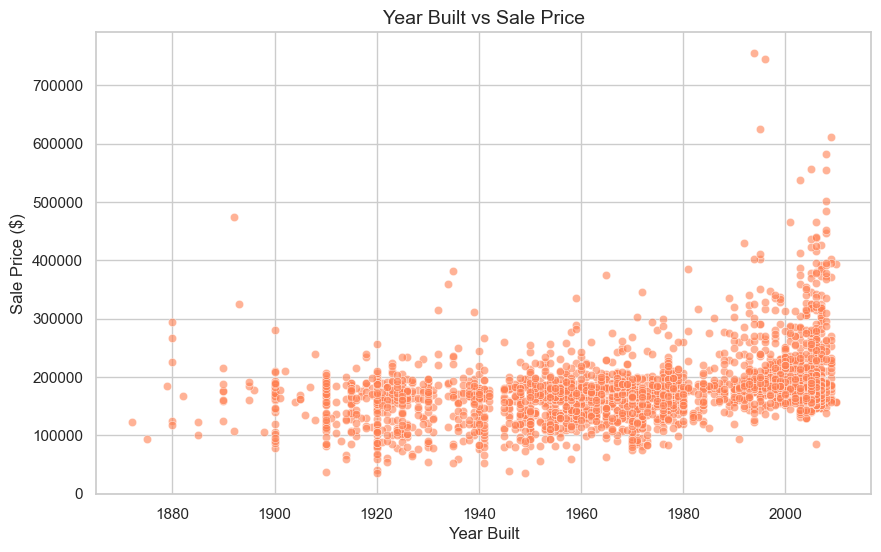

In [8]:
# Create a scatter plot of Year Built vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["YearBuilt"], y=df["SalePrice"], alpha=0.6, color="coral")

# Add title and labels
plt.title("Year Built vs Sale Price", fontsize=14)
plt.xlabel("Year Built", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)

# Display graph
plt.show()


---
# 6. Correlation Matrix




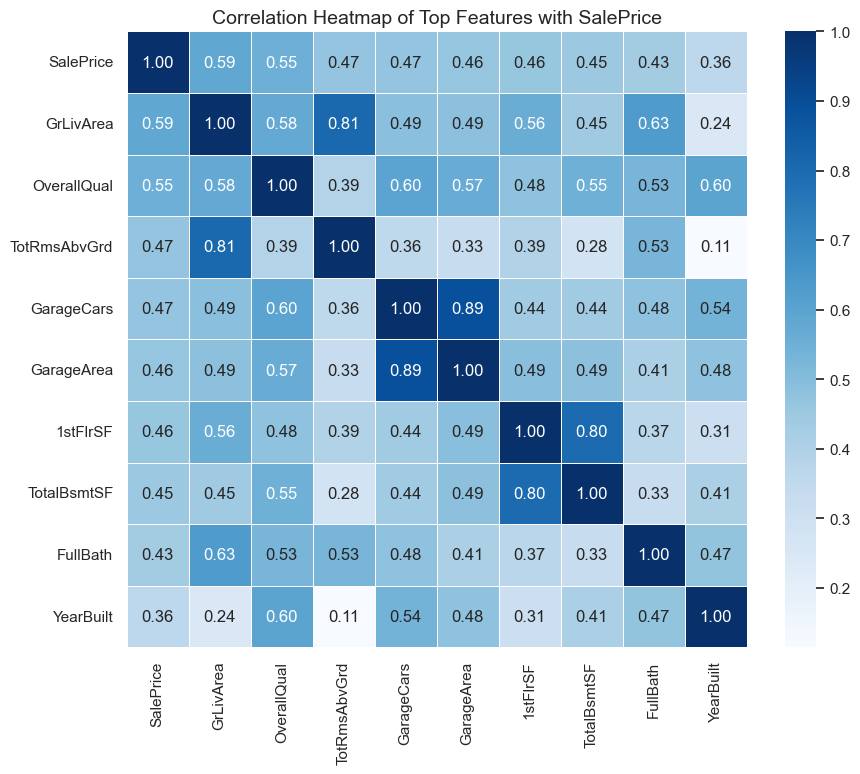

In [ ]:
# Select only numerical columns from our dataframe
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Get the top 10 features most correlated with SalePrice
top_corr_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(10).index

# Extract sub-correlation matrix for top features
top_corr_matrix = numeric_df[top_corr_features].corr()

# Plot heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

# Add title
plt.title("Correlation Heatmap of Top Features with SalePrice", fontsize=14)

# Display heatmap
plt.show()
